In [1]:
from __future__ import annotations
import operator
from typing import TypedDict,List,Annotated, Literal, Optional
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_google_genai import ChatGoogleGenerativeAI


from dotenv import load_dotenv
load_dotenv()


c:\Users\maaz7\OneDrive\Desktop\langgraphcampusx\planning agent\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\maaz7\AppData\Local\Temp\ipykernel_2592\458925710.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


True

In [2]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(...,description="one sentence describing what the reader should be able to do/understand after this section")
    bullets: List[str] = Field(min_length=1,max_length=3,description="1-3 concrete, non-overlapping subpoints to cover in this section."
    )
    target_words: int = Field(..., description="Target word count for this section (120-350).")
    tags: List[str] = Field(default_factory=list)
    requires_research: bool=False
    requires_citations: bool=False
    requires_code: bool=False


In [3]:
class Plan(BaseModel):
    blog_title: str
    audience: str= Field(..., description="Who this blog is for.")
    tone: str = Field(..., description="Writing tone (for example, practical, crisp, technical).")
    constraints: List[str] =Field(default_factory=list)
    tasks: List[Task]

class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] =None
    snippet: Optional[str]=None
    source: Optional[str] =None
class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book","hybrid","open_book"]
    queries: List[str]=Field(default_factory=list)

class EvidencePack(BaseModel):
    evidence: List[EvidenceItem]=Field(default_factory=list)

class ImageSpec(BaseModel):
    section_title: str = Field(
    description="Exact markdown heading including ##, for example: ## Self-Attention Mechanism"
    )
    # placeholder: str=Field(description="for example, [[Image_1]]")
    filename: str=Field(description="Save under images/, e.g. gkv_flow.png")
    alt: str
    caption: str
    prompt: str=Field(description="Prompt to send to the image model")
    size: Literal["1024x1024","1024x1536","1536x1024"]="1024x1024"
    quality: Literal["low","medium","high"]="medium"

# class ImagePlaceholder(BaseModel):
#     md_with_placeholder: str
#     images: List[ImageSpec]=Field(default_factory=list)
class ImagePlan(BaseModel):
    images: List[ImageSpec] = Field(default_factory=list)

In [4]:
class State(TypedDict):
    topic: str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    sections: Annotated[List[tuple[int, str]], operator.add]
    as_of: str
    recency_days: int
    merged_md: str
    # md_with_placeholder: str
    image_specs: List[dict]

    final: str

In [ ]:
groq_llm=ChatGroq(model="llama-3.3-70b-versatile",temperature=0)

In [6]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)

In [7]:
ROUTER_SYSTEM = """
you are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
Evergreen topics where corrections does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
Mostly evergreeen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 1-3 high-signal queries.
- Queries should be scoped and specific (avoid generic queeries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

def router_node(state: State)-> dict:
    topic= state["topic"]
    decider=groq_llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}")
        ]

    )
    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

def route_next(state: State)-> dict:
    return "research" if state["needs_research"] else "orchestrator"

In [8]:
import json
def _tavily_search(query: str, max_results: int=2)->List[dict]:

    tool=TavilySearchResults(max_results=max_results)
    results=tool.invoke({"query": query})

    normalised: List[dict] = []
    for r in results or []:
        normalised.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "snippet": r.get("content") or r.get("snippet") or "",
                "source": r.get("source"),

            }
        )
    return normalised

RESEARCH_SYSTEM="""
You are a research system for technical writing.
Given raw web search results, produce a deduplicated list of EvidenceItem objects.
Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, documentation, reputable outlets)
- If a published date is present in the result, keep it as it is YYYY-MM-DD. If it is unclear or not present. Do not guess, set published_at=null.
- Do not repeat the items by URL

"""
def research_node(state: State)->dict:

    queries= (state.get("queries",[]) or [])
    max_results=1
    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))
    
    if not raw_results:
        return {"evidence": []}
    
    compressed_results = []

    for r in raw_results:
        compressed_results.append({
            "title": r["title"],
            "url": r["url"],
            "published_at": r["published_at"],
            "snippet": (r["snippet"] or "")[:200],   # limit to 200 chars
            "source": r["source"],
        })
    
    extractor = groq_llm.with_structured_output(EvidencePack)
    pack=extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results:\n{json.dumps(compressed_results, indent=2)}")
        ]
    )
    dedup={}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
    return {"evidence": list(dedup.values())}

In [9]:
def orchestrator(state: State)->dict:

    evidence=state.get("evidence", [])
    mode=state.get("mode","closed_book")
    plan = groq_llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(content=("You are an experienced editor creating outlines for high-quality technical blogs.\n\n"
        "Your task is to generate a comprehensive blog plan that includes:\n"
        "- An engaging, descriptive blog title.\n"
        "- 2 to 4 well-organized sections.\n"
        "- Each section should build upon the previous one.\n"
        "- Every section must have:\n"
        "  • A clear, informative title.\n"
        "  • A brief explaining the main ideas to discuss.\n\n"
        "Guidelines:\n"
        "- Start with an introduction.\n"
        "- Explain core concepts before advanced topics.\n"
        "- Include practical examples or applications where appropriate.\n"
        "- End with best practices, future directions, or a conclusion.\n"
        "- Avoid duplicate or overlapping sections.\n"
        "-Keep every goal to one sentence. Keep every bullet under 10 words.")),
            HumanMessage(content=f"Topic: {state['topic']}\n"
                         f"Mode: {mode}\n\n"
                         f"Evidence (only use for fresh claims; may be empty):\n"
                         f"{[e.model_dump() for e in evidence] [:16]}"
                         )
        ]
    )
    return {"plan": plan}

In [10]:
def fanout(state: State):
    return [Send(
        "worker", 
        {
            "task": task.model_dump(),
             "topic":state['topic'],
             "mode": state["mode"],
             "plan": state['plan'].model_dump(),
              "evidence": [e.model_dump() for e in state.get("evidence",[])] }
              ) for task in state['plan'].tasks
              ]

In [11]:
def worker(payload: dict)-> dict:
    task = Task(**payload["task"])
    topic = payload["topic"]
    plan = Plan(**payload['plan'])
    evidence=[EvidenceItem(**e) for e in payload.get("evidence",[])]
    mode=payload.get("mode", "closed_book")

    bullet_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text=""
    if evidence:
        evidence_text="\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    section_md = groq_llm.invoke(
        [
        SystemMessage(content="You are a senior technical content writer specializing in AI and software engineering.\n\n"
        "Generate a high-quality Markdown section that is informative, engaging, "
        "and technically accurate.\n\n"
        "Requirements:\n"
        "- Begin with a `##` Markdown heading.\n"
        "- Cover the assigned topic thoroughly without discussing other sections.\n"
        "- Explain complex ideas in simple language.\n"
        "- Use examples, bullet lists, or short code snippets only when they improve understanding.\n"
        "- Keep a logical flow from one paragraph to the next.\n"
        "- Avoid repetition, filler text, and generic statements.\n"
        "- Return only the Markdown content for this section."),
        HumanMessage(
            content=(
                f"Blog title: {plan.blog_title}\n"
                f"Audience: {plan.audience}\n"
                f"Tone: {plan.tone}\n"
                f"Topic: {topic}\n"
                f"Section: {task.title}\n"
                f"Mode: {mode}\n\n"
                f"requires_research: {task.requires_research}\n"
                f"requires_citations: {task.requires_citations}\n"
                f"requires_code: {task.requires_code}\n"
                f"Goal: {task.goal}\n\n"
                f"Target words: {task.target_words}\n"
                f"Bullets: {bullet_text}\n"
                f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
            )
        ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

In [18]:
import re
from pathlib import Path

def merge_content(state: State)-> dict:
    plan=state["plan"]
    ordered_sections=[md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"
    return {"merged_md":merged_md}

DECIDE_IMAGES_SYSTEM="""You are an expert technical editor.

Your job is to decide whether a technical diagram would improve the article.

Return ONLY JSON matching the ImagePlan schema.

Rules:
- Maximum one image.
- Never rewrite or summarize the article.
- Never return markdown.
- Never return placeholders.
- section_title must exactly match an existing H2 heading.
- Prefer architecture diagrams, flowcharts, pipelines, algorithms, or system diagrams.
- If no image is useful, return:
  {{"images":[]}}
"""

def decide_images(state: State)-> dict:
    planner=groq_llm.with_structured_output(ImagePlan)
    merged_md=state["merged_md"]
    plan=state["plan"]
    assert plan is not None

    

    image_plan=planner.invoke(
        [
            SystemMessage(content=DECIDE_IMAGES_SYSTEM),
            HumanMessage(content=f"""
    Topic:
    {state['topic']}

    Below is a complete markdown article.

    Your task is ONLY to decide whether one technical diagram would improve the article.

    Return JSON matching the ImagePlan schema.

    Rules:
    - Return at most ONE image.
    - Do NOT rewrite the article.
    - Do NOT return markdown.
    - Do NOT insert placeholders.
    - section_title must exactly match one existing H2 heading in the article,
    WITHOUT the leading ## because the code will add it automatically.
    - filename should end with .png.
    - prompt should be detailed enough for an image model to generate the diagram.
    - Prefer diagrams such as architectures, workflows, pipelines, or flowcharts.
    - If no image is needed, return:
    {{"images": []}}

    Markdown article:

    {merged_md}
    """)
            ]
        )

    return {
    "image_specs": [img.model_dump() for img in image_plan.images]
    }


    # return {
    #     "md_with_placeholder": image_plan.md_with_placeholder,
    #     "image_specs": [img.model_dump() for img in image_plan.images],
    # }

def _gemini_generate_image_bytes(prompt: str) -> bytes:
    """
    Returns raw image bytes generated by Gemini.
    Requires: pip install google-genai
    Env var: GOOGLE_API_KEY
    """
    from google import genai
    from google.genai import types
    import os

    api_key = os.environ.get("GOOGLE_API_KEY")
    if not api_key:
        raise RuntimeError("GOOGLE_API_KEY is not set.")

    client = genai.Client(api_key=api_key)

    resp = client.models.generate_content(
        model="gemini-2.5-flash-image",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE"],
            safety_settings=[
                types.SafetySetting(
                    category="HARM_CATEGORY_DANGEROUS_CONTENT",
                    threshold="BLOCK_ONLY_HIGH",
                )
            ],
        ),
    )

    # Depending on SDK version, parts may hang off resp.candidates[0].content.parts
    parts = getattr(resp, "parts", None)
    if not parts and getattr(resp, "candidates", None):
        try:
            parts = resp.candidates[0].content.parts
        except Exception:
            parts = None

    if not parts:
        raise RuntimeError("No image content returned (safety/quota/SDK change).")

    for part in parts:
        inline = getattr(part, "inline_data", None)
        if inline and getattr(inline, "data", None):
            return inline.data

    raise RuntimeError("No inline image bytes found in response.")

def generate_image_save(state: State) -> dict:
    plan = state["plan"]
    assert plan is not None

    md = state["merged_md"]
    image_specs = state.get("image_specs", []) or []

    if not image_specs:
        Path(f"{plan.blog_title}.md").write_text(md, encoding="utf-8")
        return {"final": md}

    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    # Insert placeholders
    for i, spec in enumerate(image_specs, start=1):
        placeholder = f"[[Image_{i}]]"
        heading = spec['section_title']

        
        if heading in md:
            md = md.replace(
                heading,
                heading + "\n\n" + placeholder,
                1,
            )

    

    # Generate images
    for i, spec in enumerate(image_specs, start=1):
        placeholder = f"[[Image_{i}]]"

        filename = spec["filename"]
        out_path = images_dir / filename

        if not out_path.exists():
            try:
                img_bytes = _gemini_generate_image_bytes(spec["prompt"])
                out_path.write_bytes(img_bytes)
            except Exception as e:
                md = md.replace(
                    placeholder,
                    (
                        f"> **[IMAGE GENERATION FAILED]** {spec['caption']}\n>\n"
                        f"> **Prompt:** {spec['prompt']}\n>\n"
                        f"> **Error:** {e}\n"
                    ),
                )
                continue

        img_md = (
            f"![{spec['alt']}](images/{filename})\n\n"
            f"*{spec['caption']}*"
        )

        md = md.replace(placeholder, img_md)

    Path(f"{plan.blog_title}.md").write_text(md, encoding="utf-8")

    return {"final": md}

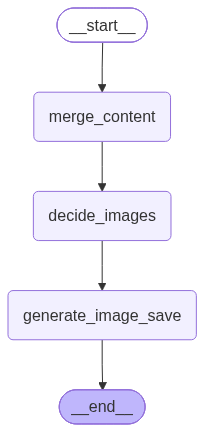

In [19]:
reducer_graph=StateGraph(State)
reducer_graph.add_node("merge_content",merge_content)
reducer_graph.add_node("decide_images",decide_images)
reducer_graph.add_node("generate_image_save",generate_image_save)
reducer_graph.add_edge(START,"merge_content")
reducer_graph.add_edge("merge_content", "decide_images")
reducer_graph.add_edge( "decide_images","generate_image_save")
reducer_graph.add_edge("generate_image_save", END)

reducer_subgraph=reducer_graph.compile()

reducer_subgraph



In [20]:
graph = StateGraph(State)

graph.add_node("router", router_node)
graph.add_node("research", research_node)
graph.add_node("orchestrator",orchestrator)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer_subgraph)

graph.add_edge(START, "router")
graph.add_conditional_edges("router", route_next, {"research":"research","orchestrator": "orchestrator"})
graph.add_edge("research","orchestrator")

graph.add_conditional_edges("orchestrator", fanout, ["worker"])
graph.add_edge("worker","reducer")
graph.add_edge("reducer",END)

workflow = graph.compile()

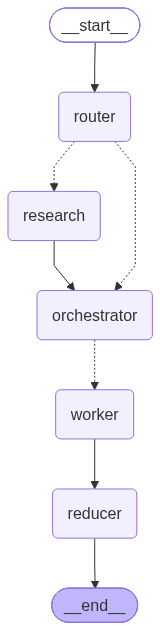

In [21]:
workflow

In [22]:
from datetime import date
def run(topic: str, as_of: Optional[str]=None):
    if as_of is None:
        as_of = date.today().isoformat()
    res = workflow.invoke(
        {
            "topic":topic,
            "mode":"",
            "needs_research":False,
            "queries":[],
            "evidence":[],
            "plan":None,
            "as_of":as_of,
            "recency_days": 7,
            "merged_md":"",
            # "md_with_placeholder": "",
            "image_specs": [],

            "sections":[],
            "final":"",
            })
    return res

In [23]:
run("Self attention in transformers architecture")


{'topic': 'Self attention in transformers architecture',
 'mode': 'closed_book',
 'needs_research': False,
 'queries': [],
 'evidence': [],
 'plan': Plan(blog_title='Unlocking Self-Attention in Transformers', audience='AI enthusiasts', tone='technical', constraints=[], tasks=[Task(id=1, title='Introduction to Transformers', goal='Understand transformer basics', bullets=['Transformers', 'Architecture', 'History'], target_words=200, tags=['AI', 'ML'], requires_research=False, requires_citations=False, requires_code=False), Task(id=2, title='Self-Attention Mechanism', goal='Learn self-attention mechanism', bullets=['Attention', 'Weights', 'Layers'], target_words=250, tags=['Deep Learning', 'NLP'], requires_research=False, requires_citations=False, requires_code=False), Task(id=3, title='Applications and Best Practices', goal='Apply self-attention in real-world scenarios', bullets=['NLP', 'Vision', 'Tips'], target_words=220, tags=['Practical', 'Future'], requires_research=False, requires_c